# 03 — Neural Collaborative Filtering (NCF)
Implements He et al. (2017): GMF branch + MLP branch fused for final prediction.
Trains on both MovieLens 100K (explicit) and LastFM-2K (implicit).
**Requires:** `01_data_preprocessing.ipynb` and `02_baseline.ipynb` to have been run first.

In [1]:
import pandas as pd
import numpy as np
import pickle, time
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

ROOT    = Path('..').resolve()
PROC    = ROOT / 'data' / 'processed'
DEVICE  = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {DEVICE}')
print(f'Looking for processed data in: {PROC}')

def load_dataset(name):
    p     = PROC / name
    train = pd.read_parquet(p / 'train.parquet')
    val   = pd.read_parquet(p / 'val.parquet')
    test  = pd.read_parquet(p / 'test.parquet')
    meta  = pickle.load(open(p / 'meta.pkl','rb'))
    return train, val, test, meta

ml_train, ml_val, ml_test, ml_meta = load_dataset('ml-100k')
n_users_ml, n_items_ml = ml_meta['n_users'], ml_meta['n_items']
print(f'MovieLens: {n_users_ml:,} users, {n_items_ml:,} items')

lf_train, lf_val, lf_test, lf_meta = load_dataset('lastfm-2k')
n_users_lf, n_items_lf = lf_meta['n_users'], lf_meta['n_items']
print(f'LastFM-2K: {n_users_lf:,} users, {n_items_lf:,} items')

Using device: cpu
Looking for processed data in: /Users/XuanNguyen/Documents/NUS/DSS5104/dss5104_recommendation_system/data/processed
MovieLens: 938 users, 1,008 items
LastFM-2K: 1,859 users, 2,823 items


## Evaluation metrics

In [2]:
def hit_rate_at_k(recs, gt, k=10):
    hits, total = 0, 0
    for u, r in recs.items():
        g = set(gt.get(u, []))
        if not g: continue
        hits += int(len(set(r[:k]) & g) > 0); total += 1
    return hits / total if total else 0.0

def ndcg_at_k(recs, gt, k=10):
    scores = []
    for u, r in recs.items():
        g = set(gt.get(u, []))
        if not g: continue
        dcg  = sum(1/np.log2(i+2) for i,it in enumerate(r[:k]) if it in g)
        idcg = sum(1/np.log2(i+2) for i in range(min(len(g),k)))
        scores.append(dcg/idcg if idcg else 0.0)
    return float(np.mean(scores)) if scores else 0.0

def map_at_k(recs, gt, k=10):
    aps = []
    for u, r in recs.items():
        g = set(gt.get(u, []))
        if not g: continue
        hits, ps = 0, 0.0
        for rank, it in enumerate(r[:k]):
            if it in g: hits += 1; ps += hits/(rank+1)
        aps.append(ps / min(len(g),k))
    return float(np.mean(aps)) if aps else 0.0

def all_metrics(recs, gt, k=10):
    return {f'hr@{k}': hit_rate_at_k(recs,gt,k),
            f'ndcg@{k}': ndcg_at_k(recs,gt,k),
            f'map@{k}':  map_at_k(recs,gt,k)}

def cold_start_metrics(recs, test_df, k=10):
    gt_all  = test_df.groupby('user_id')['item_id'].apply(list).to_dict()
    cold    = set(test_df[test_df.cold_start==True].user_id)
    regular = set(test_df[test_df.cold_start==False].user_id)
    return {
        'cold_start': all_metrics({u:r for u,r in recs.items() if u in cold},
                                   {u:g for u,g in gt_all.items() if u in cold}, k),
        'regular':    all_metrics({u:r for u,r in recs.items() if u in regular},
                                   {u:g for u,g in gt_all.items() if u in regular}, k),
    }
print('Metrics defined.')

Metrics defined.


## Dataset — implicit negative sampling

In [3]:
class ImplicitDataset(Dataset):
    """
    Each positive (user, item) pair is paired with n_neg randomly sampled
    negative items. Negatives are sampled online each epoch (data augmentation).
    """
    def __init__(self, df, n_items, n_neg=4):
        self.users    = df['user_id'].values
        self.items    = df['item_id'].values
        self.n_items  = n_items
        self.n_neg    = n_neg
        self.user_pos = df.groupby('user_id')['item_id'].apply(set).to_dict()

    def __len__(self):
        return len(self.users) * (1 + self.n_neg)

    def __getitem__(self, idx):
        pos_idx = idx // (1 + self.n_neg)
        is_neg  = (idx % (1 + self.n_neg)) != 0
        user    = self.users[pos_idx]
        if not is_neg:
            return (torch.tensor(user, dtype=torch.long),
                    torch.tensor(self.items[pos_idx], dtype=torch.long),
                    torch.tensor(1.0))
        pos = self.user_pos.get(user, set())
        while True:
            neg = np.random.randint(0, self.n_items)
            if neg not in pos: break
        return (torch.tensor(user, dtype=torch.long),
                torch.tensor(neg, dtype=torch.long),
                torch.tensor(0.0))

print('ImplicitDataset defined.')

ImplicitDataset defined.


## NCF model

In [4]:
class NCF(nn.Module):
    """
    Neural Collaborative Filtering (He et al., 2017).
    Two parallel branches:
      - GMF: element-wise product of separate user/item embeddings
      - MLP: concatenated embeddings through a stack of linear layers
    Outputs are concatenated and projected to a scalar score.
    """
    def __init__(self, n_users, n_items, gmf_dim=64,
                 mlp_dims=(128, 64, 32), dropout=0.2):
        super().__init__()
        # Separate embedding tables for each branch
        self.gmf_user = nn.Embedding(n_users, gmf_dim)
        self.gmf_item = nn.Embedding(n_items, gmf_dim)
        self.mlp_user = nn.Embedding(n_users, mlp_dims[0])
        self.mlp_item = nn.Embedding(n_items, mlp_dims[0])

        # MLP stack — input is concat of user+item embeddings
        layers, in_dim = [], mlp_dims[0] * 2
        for out_dim in mlp_dims[1:]:
            layers += [nn.Linear(in_dim, out_dim), nn.ReLU(), nn.Dropout(dropout)]
            in_dim = out_dim
        self.mlp = nn.Sequential(*layers)

        # Final fusion: GMF output (gmf_dim) + MLP output (mlp_dims[-1]) -> score
        self.output = nn.Linear(gmf_dim + mlp_dims[-1], 1)
        self._init_weights()

    def _init_weights(self):
        for emb in [self.gmf_user, self.gmf_item, self.mlp_user, self.mlp_item]:
            nn.init.normal_(emb.weight, std=0.01)
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, user_ids, item_ids):
        # GMF branch: element-wise product
        gmf_out = self.gmf_user(user_ids) * self.gmf_item(item_ids)
        # MLP branch: concat then pass through layers
        mlp_out = self.mlp(torch.cat([self.mlp_user(user_ids),
                                       self.mlp_item(item_ids)], dim=-1))
        return self.output(torch.cat([gmf_out, mlp_out], dim=-1)).squeeze(-1)

print('NCF model defined.')

NCF model defined.


## Training loop

In [5]:
def evaluate_model(model, val_df, n_items, k=10, n_neg_eval=99, device='cpu'):
    """Evaluate using sampled negatives: 1 positive + 99 negatives per user."""
    model.eval()
    user_pos = val_df.groupby('user_id')['item_id'].apply(set).to_dict()
    recs, gt = {}, {}
    with torch.no_grad():
        for uid, pos_items in user_pos.items():
            pos_list = list(pos_items)
            # Sample negatives
            negs = []
            while len(negs) < n_neg_eval:
                neg = np.random.randint(0, n_items)
                if neg not in pos_items: negs.append(neg)
            # Score positive + negatives
            candidates = pos_list + negs
            u_tensor   = torch.tensor([uid]*len(candidates), dtype=torch.long).to(device)
            i_tensor   = torch.tensor(candidates, dtype=torch.long).to(device)
            scores     = model(u_tensor, i_tensor).cpu().numpy()
            top_k      = np.argsort(scores)[::-1][:k]
            recs[uid]  = [candidates[i] for i in top_k]
            gt[uid]    = pos_list
    return all_metrics(recs, gt, k)


def train_ncf(model, train_df, val_df, n_items,
              n_epochs=30, batch_size=1024, lr=1e-3,
              n_neg=4, patience=5, device='cpu'):
    dataset   = ImplicitDataset(train_df, n_items, n_neg=n_neg)
    loader    = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=0)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, patience=2, factor=0.5)

    best_ndcg, best_state, no_improve = 0.0, None, 0
    history = []

    for epoch in range(1, n_epochs+1):
        model.train()
        total_loss = 0.0
        for users, items, labels in loader:
            users, items, labels = users.to(device), items.to(device), labels.to(device)
            optimizer.zero_grad()
            loss = F.binary_cross_entropy_with_logits(model(users, items), labels)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            total_loss += loss.item()

        val_m = evaluate_model(model, val_df, n_items, k=10, device=device)
        ndcg  = val_m['ndcg@10']
        scheduler.step(-ndcg)
        history.append({'epoch': epoch, 'loss': total_loss/len(loader), **val_m})
        print(f'Epoch {epoch:3d} | loss {total_loss/len(loader):.4f} | '
              f'HR@10 {val_m["hr@10"]:.4f} | NDCG@10 {ndcg:.4f}')

        if ndcg > best_ndcg:
            best_ndcg  = ndcg
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f'Early stopping at epoch {epoch}')
                break

    model.load_state_dict(best_state)
    return model, pd.DataFrame(history)

print('Training functions defined.')

Training functions defined.


## Train NCF on MovieLens 100K

In [6]:
# Hyperparameters — tune these for your report's sensitivity analysis
GMF_DIM   = 64
MLP_DIMS  = (128, 64, 32)
N_NEG     = 4       # negatives per positive — try 1, 4, 8
LR        = 1e-3
BATCH     = 1024
N_EPOCHS  = 30

ncf = NCF(n_users_ml, n_items_ml, gmf_dim=GMF_DIM, mlp_dims=MLP_DIMS).to(DEVICE)
total_params = sum(p.numel() for p in ncf.parameters())
print(f'NCF parameters: {total_params:,}')

t0 = time.time()
ncf, history_ncf = train_ncf(
    ncf, ml_train, ml_val, n_items_ml,
    n_epochs=N_EPOCHS, batch_size=BATCH, lr=LR,
    n_neg=N_NEG, patience=5, device=DEVICE
)
train_time_ncf = time.time() - t0
print(f'Total training time: {train_time_ncf:.1f}s')

NCF parameters: 392,257
Epoch   1 | loss 0.4382 | HR@10 0.6777 | NDCG@10 0.2288
Epoch   2 | loss 0.3880 | HR@10 0.6938 | NDCG@10 0.2521
Epoch   3 | loss 0.3671 | HR@10 0.7420 | NDCG@10 0.2717
Epoch   4 | loss 0.3491 | HR@10 0.7805 | NDCG@10 0.2950
Epoch   5 | loss 0.3362 | HR@10 0.7923 | NDCG@10 0.2991
Epoch   6 | loss 0.3271 | HR@10 0.8298 | NDCG@10 0.3135
Epoch   7 | loss 0.3203 | HR@10 0.7934 | NDCG@10 0.3113
Epoch   8 | loss 0.3126 | HR@10 0.8148 | NDCG@10 0.3140
Epoch   9 | loss 0.3084 | HR@10 0.8266 | NDCG@10 0.3191
Epoch  10 | loss 0.3032 | HR@10 0.8308 | NDCG@10 0.3208
Epoch  11 | loss 0.2988 | HR@10 0.8330 | NDCG@10 0.3279
Epoch  12 | loss 0.2944 | HR@10 0.8394 | NDCG@10 0.3254
Epoch  13 | loss 0.2901 | HR@10 0.8298 | NDCG@10 0.3251
Epoch  14 | loss 0.2857 | HR@10 0.8362 | NDCG@10 0.3265
Epoch  15 | loss 0.2767 | HR@10 0.8458 | NDCG@10 0.3333
Epoch  16 | loss 0.2745 | HR@10 0.8458 | NDCG@10 0.3327
Epoch  17 | loss 0.2700 | HR@10 0.8405 | NDCG@10 0.3290
Epoch  18 | loss 0.2681 

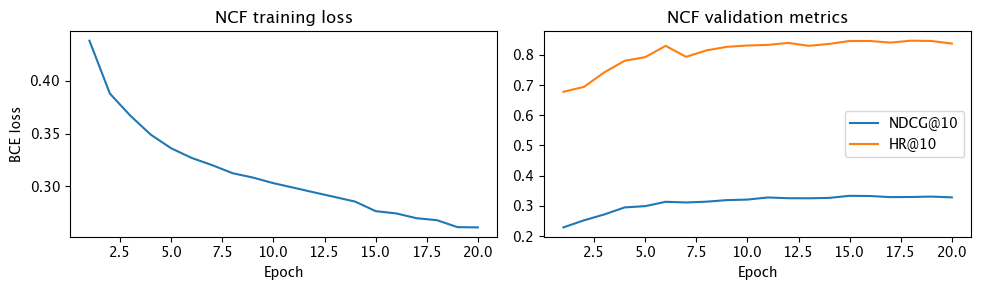

In [7]:
# Plot training curve
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3))
ax1.plot(history_ncf.epoch, history_ncf.loss)
ax1.set_title('NCF training loss')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('BCE loss')
ax2.plot(history_ncf.epoch, history_ncf['ndcg@10'], label='NDCG@10')
ax2.plot(history_ncf.epoch, history_ncf['hr@10'],   label='HR@10')
ax2.set_title('NCF validation metrics')
ax2.set_xlabel('Epoch'); ax2.legend()
plt.tight_layout()
PROC.mkdir(parents=True, exist_ok=True)
plt.savefig(PROC / 'ncf_training_curve.png', dpi=100)
plt.show()

In [8]:
# Evaluate on test set
gt_ml       = ml_test.groupby('user_id')['item_id'].apply(list).to_dict()
test_users  = ml_test.user_id.unique()

ncf_recs_ml = {}
ncf.eval()
all_items_t = torch.arange(n_items_ml, dtype=torch.long).to(DEVICE)
user_seen   = ml_train.groupby('user_id')['item_id'].apply(set).to_dict()

with torch.no_grad():
    for uid in test_users:
        u_t    = torch.tensor([uid]*n_items_ml, dtype=torch.long).to(DEVICE)
        scores = ncf(u_t, all_items_t).cpu().numpy()
        seen   = user_seen.get(uid, set())
        scores[list(seen)] = -np.inf
        top_k  = np.argsort(scores)[::-1][:10]
        ncf_recs_ml[uid] = top_k.tolist()

ncf_m_ml = all_metrics(ncf_recs_ml, gt_ml, k=10)
print('NCF test metrics — MovieLens 100K:')
print(ncf_m_ml)

print('\nCold-start breakdown:')
for group, m in cold_start_metrics(ncf_recs_ml, ml_test).items():
    print(f'  {group}: {m}')

NCF test metrics — MovieLens 100K:
{'hr@10': 0.3404710920770878, 'ndcg@10': 0.07844739958899472, 'map@10': 0.037785375977260595}

Cold-start breakdown:
  cold_start: {'hr@10': 0.4, 'ndcg@10': 0.16350587306158695, 'map@10': 0.09}
  regular: {'hr@10': 0.3401506996770721, 'ndcg@10': 0.07798960371454589, 'map@10': 0.037504350013736705}


In [9]:
# Save model and results
torch.save(ncf.state_dict(), PROC / 'ncf_movielens.pt')

ncf_results = {
    'test_metrics':    ncf_m_ml,
    'train_time_secs': train_time_ncf,
    'n_params':        total_params,
    'hyperparams':     {'gmf_dim': GMF_DIM, 'mlp_dims': MLP_DIMS,
                        'n_neg': N_NEG, 'lr': LR, 'batch': BATCH},
}
with open(PROC / 'ncf_results.pkl', 'wb') as f:
    pickle.dump(ncf_results, f)

# Load baseline metrics to compare
baseline_config = pickle.load(open(PROC / 'baseline_config.pkl', 'rb'))
summary = pd.DataFrame([
    {'Model': 'Popularity', **baseline_config['baseline_metrics']['movielens_popularity']},
    {'Model': 'SVD',        **baseline_config['baseline_metrics']['movielens_svd']},
    {'Model': 'NCF',        **ncf_m_ml},
]).round(4)
print('\nMovieLens comparison so far:')
summary


MovieLens comparison so far:


,Model,hr@10,ndcg@10,map@10
0,Popularity,0.2505,0.0533,0.0258
1,SVD,0.0535,0.0055,0.0015
2,NCF,0.3405,0.0784,0.0378


In [10]:
# Negative sampling sensitivity (required for report)
# Re-trains with different n_neg values and compares NDCG@10
print('Running negative sampling sensitivity analysis...')
neg_sensitivity = []

for n_neg_val in [1, 4, 8]:
    model_tmp = NCF(n_users_ml, n_items_ml, gmf_dim=32, mlp_dims=(64,32)).to(DEVICE)
    model_tmp, _ = train_ncf(
        model_tmp, ml_train, ml_val, n_items_ml,
        n_epochs=10, n_neg=n_neg_val, patience=3, device=DEVICE)
    val_m = evaluate_model(model_tmp, ml_val, n_items_ml, k=10, device=DEVICE)
    neg_sensitivity.append({'n_neg': n_neg_val, **val_m})
    print(f'  n_neg={n_neg_val}: NDCG@10={val_m["ndcg@10"]:.4f}')

pd.DataFrame(neg_sensitivity)

Running negative sampling sensitivity analysis...
Epoch   1 | loss 0.6205 | HR@10 0.6638 | NDCG@10 0.2309
Epoch   2 | loss 0.5230 | HR@10 0.6649 | NDCG@10 0.2348
Epoch   3 | loss 0.5138 | HR@10 0.6777 | NDCG@10 0.2344
Epoch   4 | loss 0.5051 | HR@10 0.7066 | NDCG@10 0.2524
Epoch   5 | loss 0.4858 | HR@10 0.7270 | NDCG@10 0.2673
Epoch   6 | loss 0.4659 | HR@10 0.7623 | NDCG@10 0.2785
Epoch   7 | loss 0.4489 | HR@10 0.7762 | NDCG@10 0.2849
Epoch   8 | loss 0.4372 | HR@10 0.7794 | NDCG@10 0.2940
Epoch   9 | loss 0.4295 | HR@10 0.7923 | NDCG@10 0.2997
Epoch  10 | loss 0.4210 | HR@10 0.7837 | NDCG@10 0.2985
  n_neg=1: NDCG@10=0.2978
Epoch   1 | loss 0.4503 | HR@10 0.6649 | NDCG@10 0.2297
Epoch   2 | loss 0.3870 | HR@10 0.6884 | NDCG@10 0.2400
Epoch   3 | loss 0.3710 | HR@10 0.7227 | NDCG@10 0.2677
Epoch   4 | loss 0.3541 | HR@10 0.7634 | NDCG@10 0.2815
Epoch   5 | loss 0.3440 | HR@10 0.7837 | NDCG@10 0.2932
Epoch   6 | loss 0.3350 | HR@10 0.7827 | NDCG@10 0.3003
Epoch   7 | loss 0.3293 | HR

,n_neg,hr@10,ndcg@10,map@10
0,1,0.790150,0.297847,0.185518
1,4,0.802998,0.303155,0.188053
2,8,0.796574,0.312809,0.201648


## Train NCF on LastFM-2K

In [25]:
# Hyperparameters for LastFM — can tune these
GMF_DIM_LF   = 64
MLP_DIMS_LF  = (128, 64, 32)
N_NEG_LF     = 4       # negatives per positive
LR_LF        = 1e-3
BATCH_LF     = 1024
N_EPOCHS_LF  = 30

ncf_lf = NCF(n_users_lf, n_items_lf, gmf_dim=GMF_DIM_LF, mlp_dims=MLP_DIMS_LF).to(DEVICE)
total_params_lf = sum(p.numel() for p in ncf_lf.parameters())
print(f'NCF parameters for LastFM: {total_params_lf:,}')

t0 = time.time()
ncf_lf, history_ncf_lf = train_ncf(
    ncf_lf, lf_train, lf_val, n_items_lf,
    n_epochs=N_EPOCHS_LF, batch_size=BATCH_LF, lr=LR_LF,
    n_neg=N_NEG_LF, patience=5, device=DEVICE
)
train_time_ncf_lf = time.time() - t0
print(f'Total training time: {train_time_ncf_lf:.1f}s')

NCF parameters for LastFM: 917,569
Epoch   1 | loss 0.4500 | HR@10 0.7962 | NDCG@10 0.3985
Epoch   2 | loss 0.3967 | HR@10 0.8555 | NDCG@10 0.4500
Epoch   3 | loss 0.3714 | HR@10 0.8744 | NDCG@10 0.4786
Epoch   4 | loss 0.3491 | HR@10 0.8868 | NDCG@10 0.4981
Epoch   5 | loss 0.3362 | HR@10 0.8949 | NDCG@10 0.5047
Epoch   6 | loss 0.3290 | HR@10 0.9040 | NDCG@10 0.5194
Epoch   7 | loss 0.3196 | HR@10 0.9148 | NDCG@10 0.5316
Epoch   8 | loss 0.3115 | HR@10 0.9181 | NDCG@10 0.5453
Epoch   9 | loss 0.3045 | HR@10 0.9245 | NDCG@10 0.5556
Epoch  10 | loss 0.2963 | HR@10 0.9278 | NDCG@10 0.5630
Epoch  11 | loss 0.2878 | HR@10 0.9380 | NDCG@10 0.5710
Epoch  12 | loss 0.2777 | HR@10 0.9423 | NDCG@10 0.5821
Epoch  13 | loss 0.2688 | HR@10 0.9375 | NDCG@10 0.5897
Epoch  14 | loss 0.2604 | HR@10 0.9445 | NDCG@10 0.5907
Epoch  15 | loss 0.2533 | HR@10 0.9482 | NDCG@10 0.6014
Epoch  16 | loss 0.2461 | HR@10 0.9477 | NDCG@10 0.6012
Epoch  17 | loss 0.2402 | HR@10 0.9504 | NDCG@10 0.6059
Epoch  18 | l

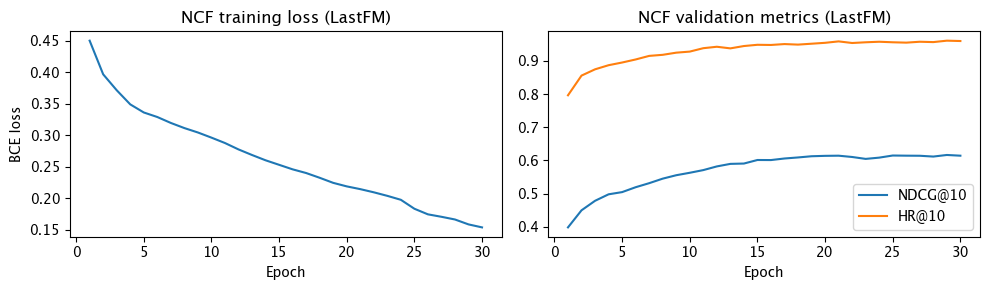

In [26]:
# Plot training curve for LastFM
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3))
ax1.plot(history_ncf_lf.epoch, history_ncf_lf.loss)
ax1.set_title('NCF training loss (LastFM)')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('BCE loss')
ax2.plot(history_ncf_lf.epoch, history_ncf_lf['ndcg@10'], label='NDCG@10')
ax2.plot(history_ncf_lf.epoch, history_ncf_lf['hr@10'],   label='HR@10')
ax2.set_title('NCF validation metrics (LastFM)')
ax2.set_xlabel('Epoch'); ax2.legend()
plt.tight_layout()
plt.savefig(PROC / 'ncf_training_curve_lastfm.png', dpi=100)
plt.show()

In [27]:
# Evaluate on LastFM test set
gt_lf       = lf_test.groupby('user_id')['item_id'].apply(list).to_dict()
test_users_lf  = lf_test.user_id.unique()

ncf_recs_lf = {}
ncf_lf.eval()
all_items_lf_t = torch.arange(n_items_lf, dtype=torch.long).to(DEVICE)
user_seen_lf   = lf_train.groupby('user_id')['item_id'].apply(set).to_dict()

with torch.no_grad():
    for uid in test_users_lf:
        u_t    = torch.tensor([uid]*n_items_lf, dtype=torch.long).to(DEVICE)
        scores = ncf_lf(u_t, all_items_lf_t).cpu().numpy()
        seen   = user_seen_lf.get(uid, set())
        scores[list(seen)] = -np.inf
        top_k  = np.argsort(scores)[::-1][:10]
        ncf_recs_lf[uid] = top_k.tolist()

ncf_m_lf = all_metrics(ncf_recs_lf, gt_lf, k=10)
print('NCF test metrics — LastFM-2K:')
print(ncf_m_lf)

print('\nCold-start breakdown:')
for group, m in cold_start_metrics(ncf_recs_lf, lf_test).items():
    print(f'  {group}: {m}')

NCF test metrics — LastFM-2K:
{'hr@10': 0.6646900269541779, 'ndcg@10': 0.19032666931490247, 'map@10': 0.10100731613400078}

Cold-start breakdown:
  cold_start: {'hr@10': 0.4, 'ndcg@10': 0.3261859507142915, 'map@10': 0.3}
  regular: {'hr@10': 0.6654054054054054, 'ndcg@10': 0.1899594820678771, 'map@10': 0.10046949806949808}


In [28]:
# Save LastFM model and results
torch.save(ncf_lf.state_dict(), PROC / 'ncf_lastfm.pt')

ncf_results_lf = {
    'test_metrics':    ncf_m_lf,
    'train_time_secs': train_time_ncf_lf,
    'n_params':        total_params_lf,
    'hyperparams':     {'gmf_dim': GMF_DIM_LF, 'mlp_dims': MLP_DIMS_LF,
                        'n_neg': N_NEG_LF, 'lr': LR_LF, 'batch': BATCH_LF},
}
with open(PROC / 'ncf_results_lastfm.pkl', 'wb') as f:
    pickle.dump(ncf_results_lf, f)

# Load baseline metrics to compare for LastFM
summary_lf = pd.DataFrame([
    {'Model': 'Popularity', **baseline_config['baseline_metrics']['lastfm_popularity']},
    {'Model': 'ALS',        **baseline_config['baseline_metrics']['lastfm_als']},
    {'Model': 'NCF',        **ncf_m_lf},
]).round(4)
print('\nLastFM-2K comparison:')
summary_lf


LastFM-2K comparison:


,Model,hr@10,ndcg@10,map@10
0,Popularity,0.3423,0.1024,0.0568
1,ALS,0.7105,0.2379,0.1382
2,NCF,0.6647,0.1903,0.1010
